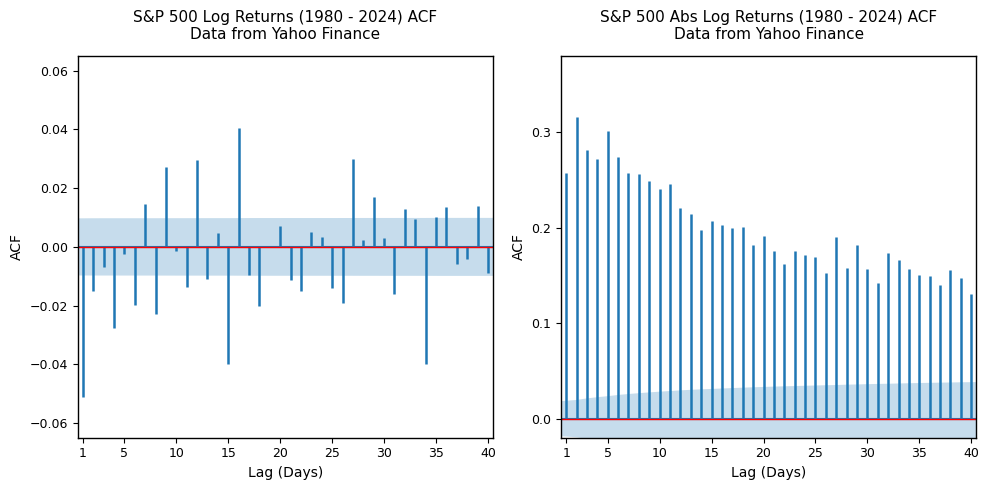

In [4]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf

# Figure 1.4 — Autocorrelation comparison
# This notebook compares the ACF of raw S&P 500 log-returns
# with the ACF of absolute log-returns to highlight volatility clustering

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2024-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Remove missing observations
df = df.dropna()

# Compute daily logarithmic returns and their absolute values
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df["Abs_Log_Returns"] = np.abs(df["Log_Returns"])
df = df.dropna()

# Figure construction with two side-by-side panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Panel 1: ACF of raw log-returns
plot_acf(
    df["Log_Returns"],
    ax=ax1,
    lags=40,
    alpha=0.30,
    title="",
    zero=False,
    marker="",
    color="#1f77b4",
    vlines_kwargs={"colors": "#1f77b4", "linewidth": 1.8}
)

ax1.set_xlim(0.5, 40.5)
ax1.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40])
ax1.axhline(y=0, color="red", linewidth=1)
ax1.set_yticks([-0.06, -0.04, -0.02, 0.0, 0.02, 0.04, 0.06])
ax1.set_ylim(-0.065, 0.065)
ax1.set_title(
    "S&P 500 Log Returns (1980 - 2024) ACF\nData from Yahoo Finance",
    pad=12
)
ax1.set_xlabel("Lag (Days)")
ax1.set_ylabel("ACF")

for spine in ax1.spines.values():
    spine.set_linewidth(1)

ax1.grid(False)

# Panel 2: ACF of absolute log-returns
plot_acf(
    df["Abs_Log_Returns"],
    ax=ax2,
    lags=40,
    alpha=0.05,
    title="",
    zero=False,
    marker="",
    color="#1f77b4",
    vlines_kwargs={"colors": "#1f77b4", "linewidth": 1.8}
)

ax2.set_xlim(0.5, 40.5)
ax2.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40])
ax2.axhline(y=0, color="red", linewidth=1)
ax2.set_yticks([0.0, 0.1, 0.2, 0.3])
ax2.set_ylim(-0.02, 0.38)
ax2.set_title(
    "S&P 500 Abs Log Returns (1980 - 2024) ACF\nData from Yahoo Finance",
    pad=12
)
ax2.set_xlabel("Lag (Days)")
ax2.set_ylabel("ACF")

for spine in ax2.spines.values():
    spine.set_linewidth(1)

ax2.grid(False)

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_1_4_acf_comparison.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()